# **Customer Personality Analysis: Marketing Campaign Report**
### by Darren Axellian Hartono

G12: "Darren and Co."

Group members:
- Muhammad Daffa
- Jeevani Anintya Putri
- Edward Budiman

In [80]:
# Install packages
install.packages("tidyverse")
install.packages("dplyr")

Warning message:
"package 'tidyverse' is in use and will not be installed"
Warning message:
"package 'dplyr' is in use and will not be installed"
Warning message:
"package 'broom' is in use and will not be installed"


In [1]:
# Libraries used
library(tidyverse)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
# Dataset taken from https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis?resource=download 
url <- "https://raw.githubusercontent.com/drrnaxl/STAT-301-Project/refs/heads/main/marketing_campaign.csv"
cpa <- read.delim(url)

## (1) Data Description

(a) The dataset contains marketing campaign data for 2,240 customers and includes 29 variables distributed as demographic variables, purchasing behaviour, and campaign responses.

In [4]:
# Number of observations & variables
glimpse(cpa)

Rows: 2,240
Columns: 29
$ ID                  <int> 5524, 2174, 4141, 6182, 5324, 7446, 965, 6177, 485…
$ Year_Birth          <int> 1957, 1954, 1965, 1984, 1981, 1967, 1971, 1985, 19…
$ Education           <chr> "Graduation", "Graduation", "Graduation", "Graduat…
$ Marital_Status      <chr> "Single", "Single", "Together", "Together", "Marri…
$ Income              <int> 58138, 46344, 71613, 26646, 58293, 62513, 55635, 3…
$ Kidhome             <int> 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,…
$ Teenhome            <int> 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,…
$ Dt_Customer         <chr> "04-09-2012", "08-03-2014", "21-08-2013", "10-02-2…
$ Recency             <int> 58, 38, 26, 26, 94, 16, 34, 32, 19, 68, 11, 59, 82…
$ MntWines            <int> 635, 11, 426, 11, 173, 520, 235, 76, 14, 28, 5, 6,…
$ MntFruits           <int> 88, 1, 49, 4, 43, 42, 65, 10, 0, 0, 5, 16, 61, 2, …
$ MntMeatProducts     <int> 546, 6, 127, 20, 118, 98, 164, 56, 24, 6, 6, 11, 4…
$ MntFishProduct

(b) Run code below for table:

In [94]:
#Table
data.frame(Type = sapply(cpa, class))

,Type
,<chr>
ID,integer
Year_Birth,integer
Education,character
Marital_Status,character
Income,integer
Kidhome,integer
Teenhome,integer
Dt_Customer,character
Recency,integer



(c) It can be assumed that the data is collected from surveys and data provided by membership subscription.

(d) Dataset is provided by Dr. Omar Romero-Hernandez. Not much else is known.
 

## (2) Question

(a) Are income, marital status, and education associated with the number of purchases done in store?

(b) We focus on inference. the question helps identify which demographic characteristics, such as income, education, and marital status, are significantly associated with wine spending and how strong those relationships are. From a prediction perspective, we may estimate how much a customer is likely to buy more wine products based on their demographic characteristics and family structure. This can help companies identify customer groups that are more likely to generate higher wine sales.

(c) The response variable is "NumStorePurchases". This variable measures the number of purchases done at the store front.

(d) The covariates expected to be most important include:

    - Income: is likely strongly associated with more purchasing power.

(e) Other variables will be used as control variables to account for demographic and household differences.

    - Education and Marital Status: These variables may reflect socioeconomic and lifestyle differences that influence spending behaviour.
  
  The remaining variables are not included in the primary model for three reasons: 
  1. Some are identifiers or administrative fields, such as ID, which do not provide explanatory value. 

  2. Several variables, such as NumWebPurchases, NumCatalogPurchases, NumDealsPurchases, and the various spending variables (MntWines, MntMeatProducts, etc.), measure purchasing behaviour very closely related to NumStorePurchases. Including them could mask or distort the effects of income, marital status, and education, since they are more like parallel or downstream measures of customer purchasing activity than baseline covariates.

  3. Adding all remaining variables would make the model harder to interpret and could introduce multicollinearity. Therefore, I restrict the model to the three selected covariates to obtain a simpler and more interpretable analysis. Other variables could be considered later in an extended model.

## (3) Exploratory Data Analysis and Visualization

### (a) Dataset loading

In [95]:
# Dataset taken from https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis?resource=download 
url <- "https://raw.githubusercontent.com/drrnaxl/STAT-301-Project/refs/heads/main/marketing_campaign.csv"
cpa <- read.delim(url)

### (b) Data cleaning and wrangling

Income is log transformed due to skewness in the distribution.

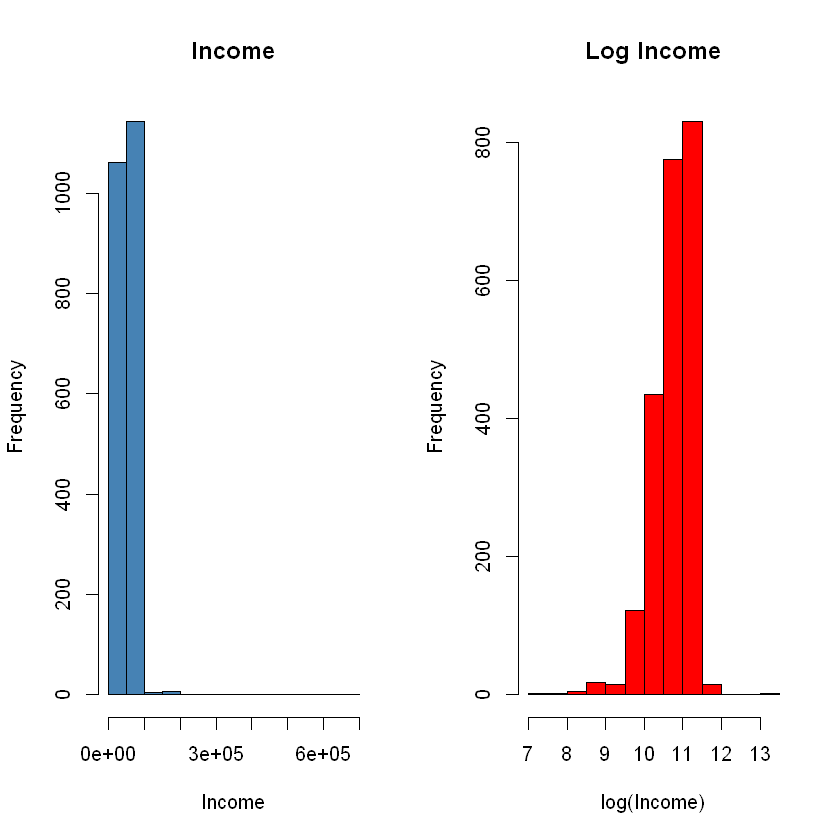

In [6]:
# Skewness
par(mfrow = c(1,2))

hist(cpa$Income,
     main = "Income",
     xlab = "Income",
     col = "steelblue")

hist(log(cpa$Income),
     main = "Log Income",
     xlab = "log(Income)",
     col = "red")

par(mfrow = c(1,1))

Since Marital_Status has many levels, it could get too complicated to include them all. Thus, I reduced the levels down to two: "In Relationship" if Married or Together, and "Single" otherwise.

In [15]:
# Cleaning and Wrangling
cpa_cleaned <- cpa |> 
    filter(
        !is.na(Income)
        ) |>
    mutate(
        Age = 2026 - Year_Birth,
        Education = as.factor(Education),
        Relationship_Status = as.factor(ifelse(Marital_Status %in% c("Married", "Together"),
                                "In Relationship",
                                "Single")),
        logIncome = log(Income),
    ) |>
select(NumStorePurchases, Age, Education, Relationship_Status, logIncome)
head(cpa_cleaned)

,NumStorePurchases,Age,Education,Relationship_Status,logIncome
,<int>,<dbl>,<fct>,<fct>,<dbl>
1,4,69,Graduation,Single,10.97057
2,2,72,Graduation,Single,10.74385
3,10,61,Graduation,In Relationship,11.17903
4,4,42,Graduation,In Relationship,10.19039
5,6,45,PhD,In Relationship,10.97324
6,10,59,Master,In Relationship,11.04313


### (c) Missing Values
There are 24 missing values from Income, with the proportion being less than 0.011. So, there are no variables with a large amount of missing data.

In [16]:
# Missing values
missing_values <- colSums(is.na(cpa))

# Missing proportions
missing_prop <- colMeans(is.na(cpa))

# Missing data table
data.frame(missing_values, missing_prop)

,missing_values,missing_prop
,<dbl>,<dbl>
ID,0,0.00000000
Year_Birth,0,0.00000000
Education,0,0.00000000
Marital_Status,0,0.00000000
Income,24,0.01071429
Kidhome,0,0.00000000
Teenhome,0,0.00000000
Dt_Customer,0,0.00000000
Recency,0,0.00000000


### (d) Class Imbalance
There is no severe class imbalance among the main categories in the dataset, though some minor imbalance exists. In Education, the largest group is Graduation, which represents about 50.3% of customers, while the rest are distributed across PhD (21.7%), Master (16.5%), 2n Cycle (9.1%), and Basic (2.4%).

For Relationship_Status, after regrouping to two levels, the largest group is In Relationship with approximately 64.53% of customers, and 35.47% Single. There is a class imbalance as more than half of the customers are in a relationship, but not severe.

Thus, the dataset does not exhibit severe class imbalance among the main categories.

In [17]:
# Class Imbalance Check
cpa_cleaned |> count(Relationship_Status) |> mutate(percentage = n / sum(n) * 100) 
cpa_cleaned |> count(Education) |> mutate(percentage = n / sum(n) * 100) 


Relationship_Status,n,percentage
<fct>,<int>,<dbl>
In Relationship,1430,64.53069
Single,786,35.46931


Education,n,percentage
<fct>,<int>,<dbl>
2n Cycle,200,9.025271
Basic,54,2.436823
Graduation,1116,50.361011
Master,365,16.471119
PhD,481,21.705776


### (e) Visualization 
To explore whether demographics and family structure influence wine spending, I created a faceted scatter plot showing the relationship between income and the number of wine purchases. Both income and wine purchases are log-transformed to reduce skewness and make patterns easier to see. Each point represents a customer, with colors indicating marital status and separate panels representing different education levels.

The plot helps in examining whether customers with higher incomes tend to purchase more wine and whether this relationship differs across demographic groups. The regression lines suggest a positive relationship between income and wine spending. Faceting by education let us compare this pattern across education levels, while the color coding highlights potential differences between marital status groups.

`geom_smooth()` using formula = 'y ~ x'


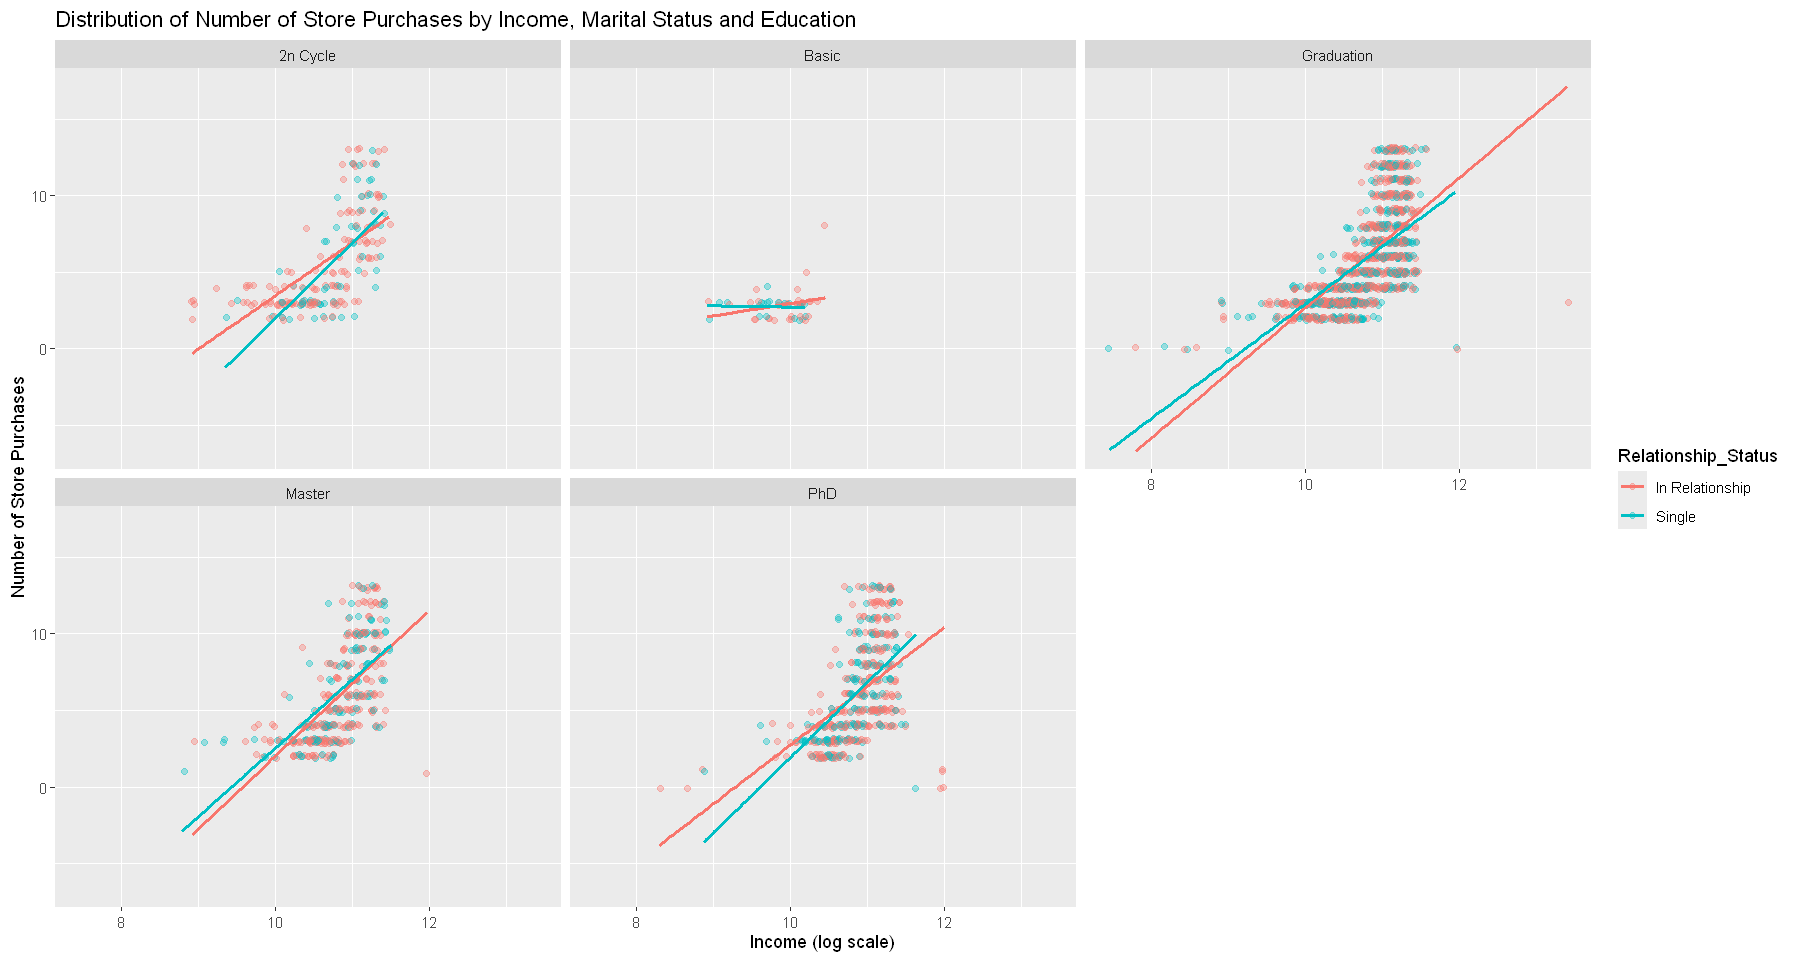

In [29]:
# Adjust accordingly
options(repr.plot.width = 15, repr.plot.height = 8)

# EDA Plot
cpa_cleaned |> 
 ggplot(aes(x = logIncome, y = NumStorePurchases, color = Relationship_Status)) +
  geom_jitter(alpha = 0.35, width = 0.03, height = 0.15) +
  facet_wrap(~Education) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Distribution of Number of Store Purchases by Income, Marital Status and Education",
    x = "Income (log scale)",
    y = "Number of Store Purchases"
  )

### (f) AI Use Disclosure
AI tools (ChatGPT) were used to assist with debugging R code and improving wording of explanations. All analysis, interpretation, and visualization design were completed independently.